In [1]:
# Core libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Make plots look a bit nicer by default
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries loaded. Ready for EDA.")

Libraries loaded. Ready for EDA.


In [2]:
# One high-quality airport station per Gulf Coast state, for regional EDA
eda_stations = {
    "USW00012960": "Houston, TX",       # you know this one
    "USW00012916": "New Orleans, LA",
    "USW00013894": "Mobile, AL",
    "USW00013865": "Meridian, MS",
    "USW00012842": "Tampa, FL",
}

# Download each, keep core columns, combine — same pattern as before
all_data = []
keep_cols = ["STATION", "DATE", "LATITUDE", "LONGITUDE", "NAME", "PRCP", "TMAX", "TMIN"]

for station_id, label in eda_stations.items():
    try:
        url = ("https://www.ncei.noaa.gov/data/"
               "global-historical-climatology-network-daily/access/"
               f"{station_id}.csv")
        df = pd.read_csv(url, low_memory=False)
        df = df[[c for c in keep_cols if c in df.columns]].copy()
        all_data.append(df)
        print(f"✓ {label}: {df.shape[0]} rows")
    except Exception as e:
        print(f"✗ {label} failed: {e}")
    time.sleep(0.5)

# Combine and clean
gulf = pd.concat(all_data, ignore_index=True)
gulf["DATE"] = pd.to_datetime(gulf["DATE"])
gulf["PRCP"] = gulf["PRCP"] / 10   # tenths mm -> mm
gulf["TMAX"] = gulf["TMAX"] / 10   # tenths °C -> °C
gulf["TMIN"] = gulf["TMIN"] / 10   # tenths °C -> °C

print("\nCombined:", gulf.shape, "|", gulf["STATION"].nunique(), "stations")

✓ Houston, TX: 20902 rows
✓ New Orleans, LA: 29546 rows
✓ Mobile, AL: 28724 rows
✓ Meridian, MS: 30856 rows
✓ Tampa, FL: 31980 rows

Combined: (142008, 8) | 5 stations


In [3]:
import pandas as pd
import time

# One station per Gulf Coast state for regional EDA
eda_stations = {
    "USW00012960": "Houston, TX",
    "USW00012916": "New Orleans, LA",
    "USW00013894": "Mobile, AL",
    "USW00013865": "Meridian, MS",
    "USW00012842": "Tampa, FL",
}

all_data = []
keep_cols = ["STATION", "DATE", "LATITUDE", "LONGITUDE", "NAME", "PRCP", "TMAX", "TMIN"]

for station_id, label in eda_stations.items():
    try:
        url = ("https://www.ncei.noaa.gov/data/"
               "global-historical-climatology-network-daily/access/"
               f"{station_id}.csv")
        df = pd.read_csv(url, low_memory=False)
        df = df[[c for c in keep_cols if c in df.columns]].copy()
        all_data.append(df)
        print(f"✓ {label}: {df.shape[0]} rows")
    except Exception as e:
        print(f"✗ {label} failed: {e}")
    time.sleep(0.5)

gulf = pd.concat(all_data, ignore_index=True)
gulf["DATE"] = pd.to_datetime(gulf["DATE"])
gulf["PRCP"] = gulf["PRCP"] / 10
gulf["TMAX"] = gulf["TMAX"] / 10
gulf["TMIN"] = gulf["TMIN"] / 10

print("\nCombined:", gulf.shape, "|", gulf["STATION"].nunique(), "stations")

✓ Houston, TX: 20902 rows
✓ New Orleans, LA: 29546 rows
✓ Mobile, AL: 28724 rows
✓ Meridian, MS: 30856 rows
✓ Tampa, FL: 31980 rows

Combined: (142008, 8) | 5 stations


In [4]:
# Give each station a readable name using our dictionary
gulf["CITY"] = gulf["STATION"].map({
    "USW00012960": "Houston, TX",
    "USW00012916": "New Orleans, LA",
    "USW00013894": "Mobile, AL",
    "USW00013865": "Meridian, MS",
    "USW00012842": "Tampa, FL",
})

# Average daily rainfall per city, and typical yearly total
print("Average DAILY rainfall (mm) per city:")
print(gulf.groupby("CITY")["PRCP"].mean().round(2).sort_values(ascending=False))

print("\nApproximate ANNUAL rainfall (mm) per city:")
# daily average × 365 gives a rough yearly total
annual = (gulf.groupby("CITY")["PRCP"].mean() * 365).round(0).sort_values(ascending=False)
print(annual)

Average DAILY rainfall (mm) per city:
CITY
Mobile, AL         4.61
New Orleans, LA    4.31
Meridian, MS       3.90
Houston, TX        3.45
Tampa, FL          3.37
Name: PRCP, dtype: float64

Approximate ANNUAL rainfall (mm) per city:
CITY
Mobile, AL         1682.0
New Orleans, LA    1573.0
Meridian, MS       1424.0
Houston, TX        1258.0
Tampa, FL          1232.0
Name: PRCP, dtype: float64


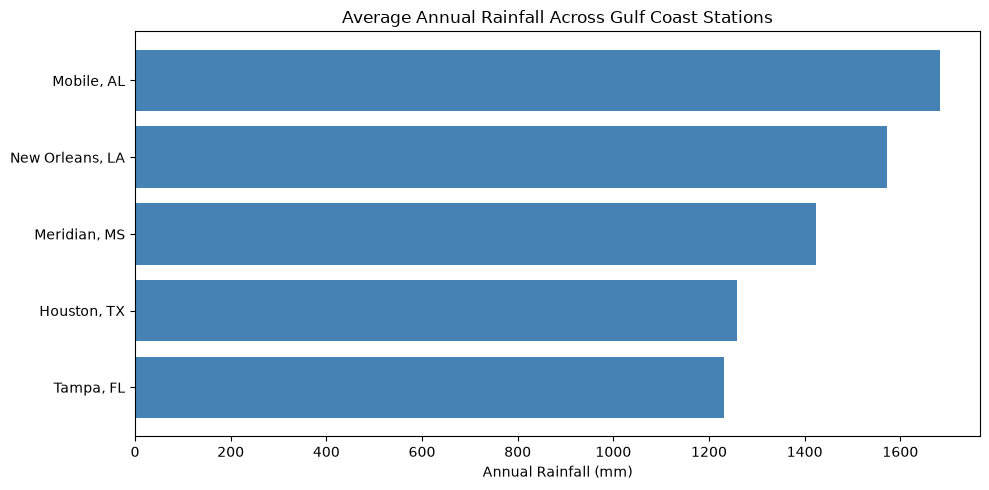

In [5]:
# Compute annual rainfall per city (daily mean × 365)
annual = (gulf.groupby("CITY")["PRCP"].mean() * 365).sort_values()

# Make a horizontal bar chart
plt.figure(figsize=(10, 5))
plt.barh(annual.index, annual.values, color="steelblue")

plt.title("Average Annual Rainfall Across Gulf Coast Stations")
plt.xlabel("Annual Rainfall (mm)")
plt.tight_layout()   # keeps labels from getting cut off
plt.show()

In [8]:
# Add a readable city name column by mapping each station code
gulf["CITY"] = gulf["STATION"].map({
    "USW00012960": "Houston, TX",
    "USW00012916": "New Orleans, LA",
    "USW00013894": "Mobile, AL",
    "USW00013865": "Meridian, MS",
    "USW00012842": "Tampa, FL",
})

print("CITY column added. Cities:", gulf["CITY"].unique())

CITY column added. Cities: <ArrowStringArray>
['Houston, TX', 'New Orleans, LA', 'Mobile, AL', 'Meridian, MS', 'Tampa, FL']
Length: 5, dtype: str


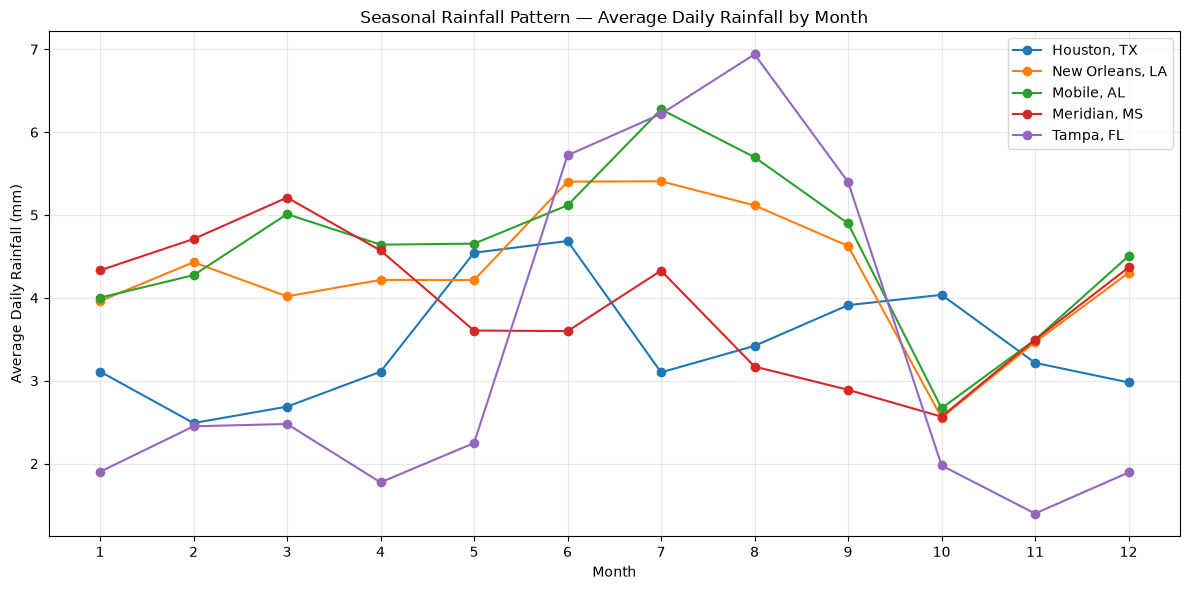

In [9]:
# Extract the month from each date (1=Jan, 12=Dec)
gulf["MONTH"] = gulf["DATE"].dt.month

# Average rainfall per month, per city
monthly = gulf.groupby(["CITY", "MONTH"])["PRCP"].mean().reset_index()

# Plot one line per city
plt.figure(figsize=(12, 6))

for city in gulf["CITY"].unique():
    city_data = monthly[monthly["CITY"] == city]
    plt.plot(city_data["MONTH"], city_data["PRCP"], marker="o", label=city)

plt.title("Seasonal Rainfall Pattern — Average Daily Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Rainfall (mm)")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()